In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import copy
import constant as const


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
url = "http://127.0.0.1:80"
testcase = 'bestest_air'
testid = \
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)
print("done")

Using: cuda
done


In [4]:
testid = \
requests.post('{0}/testcases/{1}/select'.format(url,testcase)).json()['testid']
name = requests.get('{0}/name/{1}'.format(url, testid)).json()['payload']
print(name)

{'name': 'bestest_air'}


In [5]:
step = const.step

data = pd.read_csv(f'processed_uniform_low_step_5m_data.csv')
data_test = data
data.head()

T_zone = (data['zon_reaTRooAir_y'].values - 273.15) / 30.0
T_sup  = (data['fcu_oveTSup_u'].values - 273.15) / 40.0
fan  = data['fcu_oveFan_u'].values
T_out = (data['zon_weaSta_reaWeaTDryBul_y'].values - 273.15) / 10.0


pos_T_zone = T_zone[1:]
cur_T_zone = T_zone[:-1]
cur_T_sup = T_sup[:-1]
cur_fan = fan[:-1]
cur_T_out = T_out[:-1]

def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)

def data_split(Ns, Ne, x1, x2, x3, x4, x5):
    return (to_tensor(x1[Ns:Ne]).view(-1,1), to_tensor(x2[Ns:Ne]).view(-1,1),
            to_tensor(x3[Ns:Ne]).view(-1,1), to_tensor(x4[Ns:Ne]).view(-1,1), to_tensor(x5[Ns:Ne]).view(-1,1))


Ns_tr, Ne_tr = const.Ns_tr, const.Ne_tr  
Ns_t, Ne_t = const.Ns_t, const.Ne_t 

cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr, pos_T_zone_tr = data_split(Ns_tr, Ne_tr, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)
cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t, pos_T_zone_t = data_split(Ns_t, Ne_t, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)

X_tr = torch.cat((cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr), dim=1)
y_tr = pos_T_zone_tr.squeeze(-1)  


X_t = torch.cat((cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t), dim=1)
y_t = pos_T_zone_t.squeeze(-1)

ramp = const.ramp

class NN(nn.Module):
    def __init__(self, input_dim, hidden_dim=const.hidden_dim, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim),
                                 nn.ReLU(),
                                 nn.Linear(hidden_dim, output_dim)
                                 )
    def forward(self, x):
        return self.net(x)
    
nx = 1
nu = 2
no = 1

save_path_ini='checkpoints/model_ini_AL_NN.pth'
save_path = 'checkpoints/model_PL_NN.pth'

criterion = nn.MSELoss()

def train_nn(model, X, y, epochs=20, save_path='checkpoints/model_PL_NN.pth'):
    optimizer = torch.optim.Adam(model.parameters(), lr=const.lr)
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(X).squeeze(-1)
        loss = criterion(y, preds)
        loss.backward()
        optimizer.step()

    torch.save(model.state_dict(), save_path)
    return model


In [6]:
def evaluate_NN(X_t, y_t, save_path):
    model = NN(input_dim=nx+nu+no, hidden_dim=const.hidden_dim, output_dim=nx).to(device)
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.to(device)
    model.eval()

    with torch.no_grad():
        observed_pred = model(X_t).squeeze(-1)
        rmse = torch.sqrt(torch.mean((observed_pred - y_t)**2))
    return rmse

In [7]:
evaluate_NN(X_t, y_t, save_path_ini)

tensor(1.2615, device='cuda:0')

In [8]:
class MPC:
    def __init__(self, main_NN, device='cpu'):
        self.device = device
        self.main_NN = main_NN
        self.main_NN.eval()

    def mpc_grid_search(self, u0_1, u0_2):
        n_grid = 10



        u_min_general = np.array([0.3, 0.])
        u_max_general = np.array([1.0, 1.0])

        u_min = np.clip(np.array([u0_1 - ramp, u0_2 - ramp]), u_min_general, u_max_general)
        u_max = np.clip(np.array([u0_1 + ramp, u0_2 + ramp]), u_min_general, u_max_general)

        u0_vals = np.linspace(u_min[0], u_max[0], n_grid)
        u1_vals = np.linspace(u_min[1], u_max[1], n_grid)
        
        u0 = np.random.choice(u0_vals)
        u1 = np.random.choice(u1_vals)
        best_u = np.concat((u0.reshape(-1,1), u1.reshape(-1,1)), axis=1).reshape(-1,1)

        return best_u, {
            'fcu_oveTSup_u': float(u0 * 40 + 273.15),
            'fcu_oveTSup_activate': 1,
            'fcu_oveFan_u': float(u1),
            'fcu_oveFan_activate': 1
        }

In [9]:
y = requests.put('{0}/scenario/{1}'.format(url, testid), 
                 json={'time_period':'typical_heat_day',
                       'electricity_price':'dynamic'}).json()['payload']['time_period']
requests.put('{0}/step/{1}'.format(url, testid), json={'step':const.step*60})
start_time_days = y['time']/3600/24

In [10]:
last_change_day = start_time_days
counter = 0
u0_1 = 0.5
u0_2 = 0.5
u = {'fcu_oveTSup_u': u0_1 * 40 + 273.15,
    'fcu_oveTSup_activate': 1,
    'fcu_oveFan_u': u0_2,
    'fcu_oveFan_activate': 1}
x_ref = 25
simulation_time_days = y['time']/3600/24
print('Simulation time [elapsed days] = {:.2f}'.format((simulation_time_days - start_time_days)))
y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']  

main_NN = NN(input_dim=nx+nu+no, hidden_dim=const.hidden_dim, output_dim=nx).to(device)
main_NN.load_state_dict(torch.load(save_path_ini, map_location=device))
main_NN = train_nn(main_NN, X_tr, y_tr, epochs=const.epoch_ini, save_path=save_path)

ls_rmse = [evaluate_NN(X_t, y_t, save_path=save_path)]
X_tr_new = X_tr
y_tr_new = y_tr

print("Initial RMSE:", ls_rmse[-1])

Simulation time [elapsed days] = 0.00
Initial RMSE: tensor(0.2992, device='cuda:0')


In [11]:
evaluate_NN(X_t, y_t, save_path=save_path_ini)

tensor(1.2615, device='cuda:0')

In [12]:
while y:
    x0 = y['zon_reaTRooAir_y']-273.15
    print('-------------------------------------------------------------------')
    print('Step counter =', counter)
    
    counter += 1
    mpc_controller = MPC(main_NN)
    _, u = mpc_controller.mpc_grid_search(u0_1=u0_1, u0_2=u0_2)
    y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']  
    
    cur = to_tensor(x0).view(-1,1)/30.0
    T_sup_add=  to_tensor((u['fcu_oveTSup_u']-273.15)/40.0).view(-1,1)
    fan_add = to_tensor(u['fcu_oveFan_u']).view(-1,1)
    pos_add = to_tensor(y['zon_reaTRooAir_y']-273.15).view(-1,1)/30.0
    T_out_add = to_tensor((y['zon_weaSta_reaWeaTDryBul_y']-273.15)/10.0).view(-1,1)

    X_tr_n = torch.cat((cur, T_sup_add, fan_add, T_out_add), dim=1)
    y_tr_n = pos_add.squeeze(-1)   

    X_tr_new = torch.cat((X_tr_new, X_tr_n), dim=0)
    y_tr_new = torch.cat((y_tr_new, y_tr_n), dim=0)
    
    if const.count_data == const.number_of_data:
        print("=======retrain NN model=======")
        main_NN = train_nn(main_NN, X_tr_new, y_tr_new, epochs=const.epoch_onl, save_path=save_path)
        const.count_data = 0
    
    const.count_data += 1
        
    simulation_time_days = y['time']/3600/24
    rmse = evaluate_NN(X_t, y_t, save_path=save_path)
    ls_rmse.append(rmse)

    u0_1 = (u['fcu_oveTSup_u'] - 273.15) / 40.0
    u0_2 = u['fcu_oveFan_u']

    if counter > const.num_count:
        break

-------------------------------------------------------------------
Step counter = 0
-------------------------------------------------------------------
Step counter = 1
-------------------------------------------------------------------
Step counter = 2
-------------------------------------------------------------------
Step counter = 3
-------------------------------------------------------------------
Step counter = 4
-------------------------------------------------------------------
Step counter = 5
-------------------------------------------------------------------
Step counter = 6
-------------------------------------------------------------------
Step counter = 7
-------------------------------------------------------------------
Step counter = 8
-------------------------------------------------------------------
Step counter = 9
=======retrain NN model=======
-------------------------------------------------------------------
Step counter = 10
---------------------------------

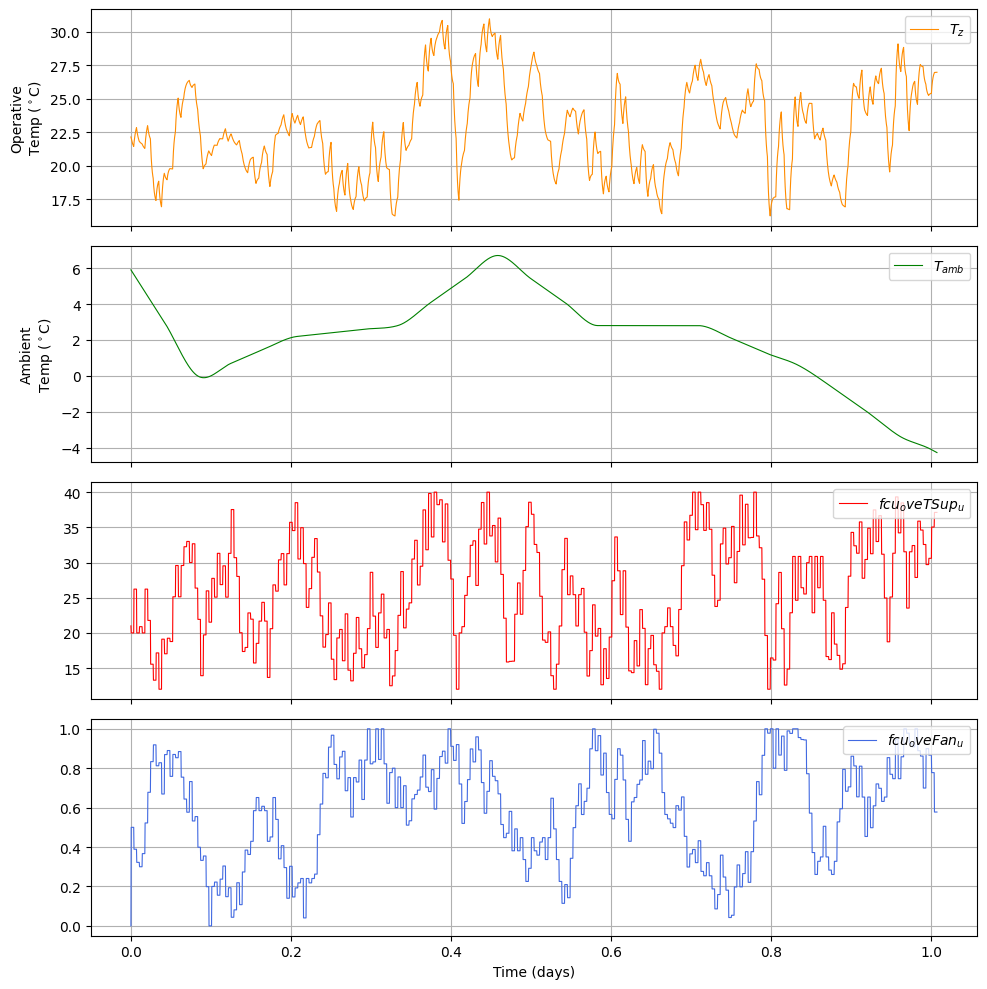

,zon_reaTRooAir_y,fcu_oveTSup_u,fcu_oveFan_u,zon_weaSta_reaWeaTDryBul_y,time
time,,,,,
3801600,295.310128,294.150000,0.000000,279.050000,0.000000
3801630,295.222125,293.150000,0.500000,279.025812,0.000347
3801660,295.117210,293.150000,0.500000,279.001625,0.000694
3801690,295.023884,293.150000,0.500000,278.977439,0.001042
3801720,294.940950,293.150000,0.500000,278.953254,0.001389
...,...,...,...,...,...
3888480,300.133116,310.270415,0.577575,268.916667,1.005556
3888510,300.135152,310.270415,0.577575,268.908333,1.005903
3888540,300.137314,310.270415,0.577575,268.900000,1.006250


In [13]:
def get_and_plot_results(testid, start_time, final_time):
    points = ['zon_reaTRooAir_y', 'fcu_oveTSup_u', 'fcu_oveFan_u', 'zon_weaSta_reaWeaTDryBul_y']
    args = {
        'point_names': points,
        'start_time': start_time, 
        'final_time': final_time
    }
    
    response = requests.put('{0}/results/{1}'.format(url, testid), json=args).json()
    
    if 'payload' not in response:
        print("Error: Could not retrieve data. Check if testid is still active.")
        return None
        
    df_res = pd.DataFrame(data=response['payload'])
    
    df_res = df_res.set_index('time')
    x_time = df_res.index / 3600. / 24.
    x_time = x_time - (start_time / 3600. / 24.)
    df_res['time'] = x_time
    
    plt.close('all')
    fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10, 10))
    
    axs[0].plot(x_time, df_res['zon_reaTRooAir_y'] - 273.15, color='darkorange', linewidth=0.8, label='$T_z$')
    axs[0].set_ylabel('Operative\nTemp ($^\circ$C)')
    axs[0].legend(loc='upper right')
    axs[0].grid(True)

    axs[1].plot(x_time, df_res['zon_weaSta_reaWeaTDryBul_y'] - 273.15, color='green', linewidth=0.8, label='$T_{amb}$')
    axs[1].set_ylabel('Ambient\nTemp ($^\circ$C)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True)

    axs[2].plot(x_time, df_res['fcu_oveTSup_u'] - 273.15, color='red', linewidth=0.8, label='$fcu_oveTSup_u$')
    axs[2].legend(loc='upper right')
    axs[2].grid(True)

    axs[3].plot(x_time, df_res['fcu_oveFan_u'], color='royalblue', linewidth=0.8, label='$fcu_oveFan_u$')
    axs[3].set_xlabel('Time (days)')
    axs[3].legend(loc='upper right')
    axs[3].grid(True)

    plt.tight_layout()
    plt.show()
    
    return df_res

start_in_seconds = start_time_days * 24 * 3600
final_in_seconds = start_in_seconds + (14 * 24 * 3600)

get_and_plot_results(testid=testid, start_time=start_in_seconds, final_time=final_in_seconds)

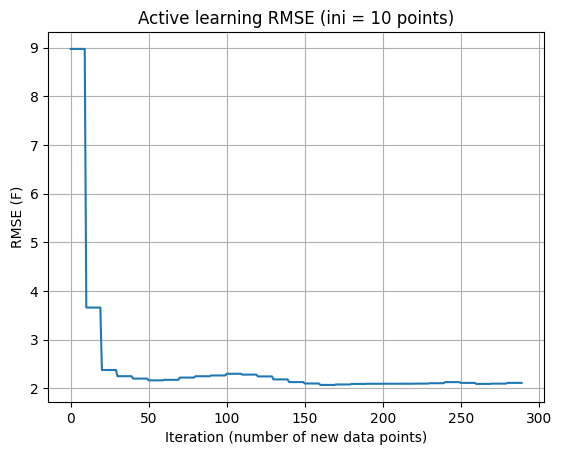

: 

In [ ]:
ls_rmse = [r.item()*30 for r in ls_rmse]    
plt.plot(ls_rmse)
plt.xlabel('Iteration (number of new data points)')
plt.grid()
plt.ylabel('RMSE (F)')
plt.title(f'Active learning RMSE (ini = {Ne_tr} points)')
plt.show()
import os
save_dir = 'results'
os.makedirs(save_dir, exist_ok=True)

df = pd.DataFrame(np.array(ls_rmse), columns=["RMSE_PL_NN"])

save_path = f"RMSE_PL_NN_ini{Ne_tr}_lr_{const.lr}_ramp_{const.ramp}.csv"                   
full_path = os.path.join(save_dir, save_path)               
df.to_csv(full_path, index=False)     